In [1]:

# clean data
# remove nan cols or all zeros
# interperlate missing nans
# remove outliers / interpolate


# plot prices
# plot ma
# plot dist
# plot pattern by year, month, day of week, hour of day
# decompose ts

# stationarity tests
# correlations
# acf, pacf, cross correlation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
df_prices = pd.read_csv(".\\data\\day_ahead_prices.csv")
df_load = pd.read_csv(".\\data\\load.csv")
df_gen = pd.read_csv(".\\data\\generation.csv")

df_prices["datetime"] = pd.to_datetime(df_prices["datetime"]).dt.tz_localize(None)
df_load["datetime"] = pd.to_datetime(df_load["datetime"]).dt.tz_localize(None)
df_gen["datetime"] = pd.to_datetime(df_gen["datetime"]).dt.tz_localize(None)

# df_prices = df_prices.set_index("datetime")
# df_load = df_load.set_index("datetime")
# df_gen = df_gen.set_index("datetime")


In [3]:
df_prices.head()

,datetime,day_ahead_prices
0,2020-01-01 00:00:00,51.24
1,2020-01-01 01:00:00,48.55
2,2020-01-01 02:00:00,36.91
3,2020-01-01 03:00:00,32.77
4,2020-01-01 04:00:00,31.69


In [4]:
df_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36741 entries, 0 to 36740
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   datetime          36741 non-null  datetime64[ns]
 1   day_ahead_prices  36741 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 574.2 KB


In [5]:
(df_prices['datetime'].max() - df_prices['datetime'].min()).days * 24

36912

In [6]:
print(f"Min day_ahead_price datetime = {df_prices['datetime'].min()}")
print(f"Max day_ahead_price datetime = {df_prices['datetime'].max()}")

Min day_ahead_price datetime = 2020-01-01 00:00:00
Max day_ahead_price datetime = 2024-03-18 00:00:00


In [7]:
df_prices = df_prices.set_index("datetime")
new_index = pd.date_range("2020-01-01", "2024-03-18",freq="1h") 
df_prices = df_prices.reindex(new_index)
df_prices.index.name = "datetime"
df_prices = df_prices.reset_index()
df_prices["date"] = df_prices["datetime"].dt.date

In [8]:
tmp = df_prices[df_prices["day_ahead_prices"].isna()]
tmp.groupby('date').size()

date
2020-10-24     2
2020-10-25    23
2021-10-30     2
2021-10-31    23
2022-10-29     2
2022-10-30    23
2023-10-28     2
2023-10-29    23
2024-01-29     1
2024-01-30    23
2024-02-12     1
2024-02-13    23
2024-02-26     1
2024-02-27    23
dtype: int64

In [9]:
df_prices["date"] = df_prices["datetime"].dt.to_period('M')
tmp = df_prices[df_prices["day_ahead_prices"]==0]
tmp.groupby('date').size()

date
2020-01     3
2020-02    24
2020-03     1
2020-04     4
2020-05     3
2020-06    20
2020-07     5
2020-09     2
2020-10     7
2020-11     5
2020-12     3
2021-01     1
2021-02     4
2021-03     3
2021-04     2
2021-05     4
2021-09     2
2021-11     1
2021-12     3
2022-01     6
2022-02     8
2022-03     3
2022-04     7
2022-05     1
2022-06     5
2022-10     3
2022-11     5
2022-12     7
2023-01     7
2023-09     4
2023-10     2
2023-12    19
2024-01     2
Freq: M, dtype: int64

In [10]:
df_load.head()

,datetime,Actual Load
0,2020-01-01 00:00:00,3855.0
1,2020-01-01 00:30:00,3761.0
2,2020-01-01 01:00:00,3635.0
3,2020-01-01 01:30:00,3523.0
4,2020-01-01 02:00:00,3426.0


In [11]:
df_load.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41220 entries, 0 to 41219
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   datetime     41220 non-null  datetime64[ns]
 1   Actual Load  41220 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 644.2 KB


In [12]:
(df_load['datetime'].max() - df_load['datetime'].min()).days * 48

73680

<Axes: title={'center': 'Load vs Time'}, xlabel='Datetime', ylabel='Load'>

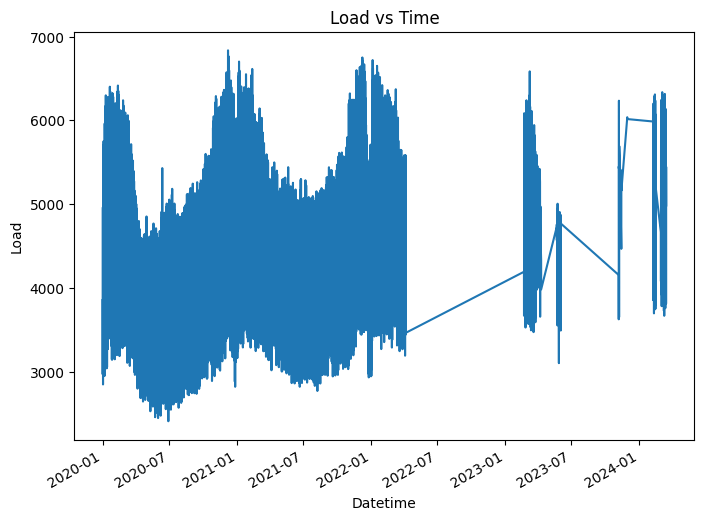

In [49]:
df_load.set_index('datetime')["Actual Load"].plot.line(xlabel='Datetime', ylabel='Load', figsize=(8,6),title='Load vs Time')

In [13]:
print(f"Min day_ahead_price datetime = {df_load['datetime'].min()}")
print(f"Max day_ahead_price datetime = {df_load['datetime'].max()}")

Min day_ahead_price datetime = 2020-01-01 00:00:00
Max day_ahead_price datetime = 2024-03-15 14:30:00


In [14]:
df_load = df_load.set_index("datetime")
new_index = pd.date_range("2020-01-01", "2024-03-15",freq="30min") 
df_load = df_load.reindex(new_index)
df_load.index.name = "datetime"
df_load = df_load.reset_index()
df_load["date"] = df_load["datetime"].dt.to_period('M')

In [15]:
tmp = df_load[df_load["Actual Load"].isna()]
tmp.groupby('date').size()

date
2020-03       2
2020-04       2
2020-05       2
2020-06      24
2020-07       8
2020-08      66
2020-09      32
2020-10     160
2020-11      20
2020-12      20
2021-01      26
2021-02       8
2021-03      12
2021-04       6
2021-05       2
2021-06       6
2021-07       8
2021-08       6
2021-09     196
2021-10     148
2021-11      76
2021-12     284
2022-01      42
2022-02      26
2022-03      24
2022-04    1194
2022-05    1488
2022-06    1440
2022-07    1488
2022-08    1488
2022-09    1440
2022-10    1488
2022-11    1440
2022-12    1488
2023-01    1488
2023-02    1014
2023-03     260
2023-04    1392
2023-05    1426
2023-06    1430
2023-07    1488
2023-08    1488
2023-09    1440
2023-10    1488
2023-11    1342
2023-12    1488
2024-01    1488
2024-02    1048
2024-03      50
Freq: M, dtype: int64

In [16]:
tmp = df_load[df_load["Actual Load"] == 0.0]
tmp.groupby('date').size()

Series([], Freq: M, dtype: int64)

In [54]:
df_gen.head()

,datetime,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Peat,Hydro Pumped Storage,Hydro Run-of-river and poundage,Other,Wind Onshore
0,2020-01-01 00:00:00,1023.0,-4.0,443.0,190.0,14.0,153.0,-1.0,319.0
1,2020-01-01 00:30:00,1025.0,-4.0,475.0,190.0,-74.0,154.0,-1.0,314.0
2,2020-01-01 01:00:00,955.0,-4.0,478.0,191.0,-74.0,150.0,-1.0,320.0
3,2020-01-01 01:30:00,790.0,-4.0,471.0,189.0,-74.0,149.0,-1.0,333.0
4,2020-01-01 02:00:00,789.0,-4.0,475.0,217.0,-149.0,150.0,-1.0,357.0


In [55]:
df_gen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66428 entries, 0 to 66427
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   datetime                         66428 non-null  datetime64[ns]
 1   Fossil Gas                       66428 non-null  float64       
 2   Fossil Hard coal                 66428 non-null  float64       
 3   Fossil Oil                       66428 non-null  float64       
 4   Fossil Peat                      66428 non-null  float64       
 5   Hydro Pumped Storage             66428 non-null  float64       
 6   Hydro Run-of-river and poundage  66428 non-null  float64       
 7   Other                            63644 non-null  float64       
 8   Wind Onshore                     66428 non-null  float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 4.6 MB


In [56]:
(df_gen['datetime'].max() - df_gen['datetime'].min()).days * 48

73776

<Axes: title={'center': 'Generation - Other vs Time'}, xlabel='Datetime', ylabel='Generation - Other'>

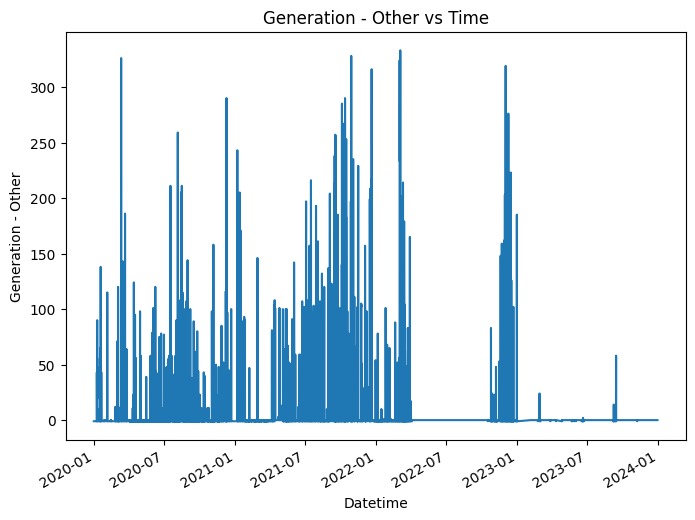

In [17]:
df_gen.set_index('datetime')["Other"].plot.line(xlabel='Datetime', ylabel='Generation - Other', figsize=(8,6),title='Generation - Other vs Time')

In [18]:
print(f"Min day_ahead_price datetime = {df_gen['datetime'].min()}")
print(f"Max day_ahead_price datetime = {df_gen['datetime'].max()}")

Min day_ahead_price datetime = 2020-01-01 00:00:00
Max day_ahead_price datetime = 2024-03-17 23:30:00


In [19]:
df_gen = df_gen.set_index("datetime")
new_index = pd.date_range("2020-01-01", "2024-03-18",freq="30min") 
df_gen = df_gen.reindex(new_index)
df_gen.index.name = "datetime"
df_gen = df_gen.reset_index()
df_gen["date"] = df_gen["datetime"].dt.to_period('M')

In [20]:
tmp = df_gen[df_gen["Other"].isna()]
tmp.groupby('date').size()

date
2020-02      18
2020-04       2
2020-05       2
2020-08      10
2020-09      16
2020-10     160
2020-11       4
2020-12      16
2021-05       8
2021-07       2
2021-08       8
2021-09     126
2021-10      10
2021-11      28
2021-12      26
2022-03       2
2022-04     120
2022-05      10
2022-06      12
2022-07      16
2022-08    1020
2022-09    1440
2022-10     624
2022-11     122
2022-12     318
2023-01    1428
2023-02      54
2023-04     750
2023-05      30
2023-06      12
2023-08      22
2023-09       8
2023-10       4
2023-11       2
2023-12      54
2024-01    1488
2024-02    1392
2024-03     817
Freq: M, dtype: int64

In [31]:
df_gen[(df_gen["datetime"] >= '2023-12-30 23:00:00')].head(20)

,datetime,Fossil Gas,Fossil Hard coal,Fossil Oil,Fossil Peat,Hydro Pumped Storage,Hydro Run-of-river and poundage,Other,Wind Onshore,date
70078,2023-12-30 23:00:00,0.0,0.0,0.0,41.0,-147.0,176.0,0.0,0.0,2023-12
70079,2023-12-30 23:30:00,0.0,0.0,0.0,41.0,-147.0,177.0,0.0,0.0,2023-12
70080,2023-12-31 00:00:00,0.0,0.0,0.0,41.0,-147.0,176.0,NaN,0.0,2023-12
70081,2023-12-31 00:30:00,0.0,0.0,0.0,41.0,-146.0,177.0,NaN,0.0,2023-12
70082,2023-12-31 01:00:00,0.0,0.0,0.0,41.0,-146.0,176.0,NaN,0.0,2023-12
70083,2023-12-31 01:30:00,0.0,0.0,0.0,41.0,-146.0,177.0,NaN,0.0,2023-12
70084,2023-12-31 02:00:00,0.0,0.0,0.0,41.0,-145.0,178.0,NaN,0.0,2023-12
70085,2023-12-31 02:30:00,0.0,0.0,0.0,41.0,-144.0,178.0,NaN,0.0,2023-12
70086,2023-12-31 03:00:00,0.0,0.0,0.0,41.0,-143.0,177.0,NaN,0.0,2023-12
70087,2023-12-31 03:30:00,0.0,0.0,0.0,41.0,-143.0,178.0,NaN,0.0,2023-12
